In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

# Case Study 1: Time Series

In [2]:
df_energy = pd.read_csv('AEP_hourly.csv', parse_dates=['Datetime'])
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[ns]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.9 MB


In [3]:
df_energy.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [5]:
# feature extraction on date
df_energy['hour'] = df_energy['Datetime'].dt.hour
df_energy['day'] = df_energy['Datetime'].dt.day
df_energy['month'] = df_energy['Datetime'].dt.month
df_energy['year'] = df_energy['Datetime'].dt.year
df_energy['dayofweek'] = df_energy['Datetime'].dt.dayofweek
df_energy['weekofyear'] = df_energy['Datetime'].dt.isocalendar().week

df_energy.head(10)

,Datetime,AEP_MW,hour,day,month,year,dayofweek,weekofyear
0,2004-12-31 01:00:00,13478.0,1,31,12,2004,4,53
1,2004-12-31 02:00:00,12865.0,2,31,12,2004,4,53
2,2004-12-31 03:00:00,12577.0,3,31,12,2004,4,53
3,2004-12-31 04:00:00,12517.0,4,31,12,2004,4,53
4,2004-12-31 05:00:00,12670.0,5,31,12,2004,4,53
5,2004-12-31 06:00:00,13038.0,6,31,12,2004,4,53
6,2004-12-31 07:00:00,13692.0,7,31,12,2004,4,53
7,2004-12-31 08:00:00,14297.0,8,31,12,2004,4,53
8,2004-12-31 09:00:00,14719.0,9,31,12,2004,4,53
9,2004-12-31 10:00:00,14941.0,10,31,12,2004,4,53


In [6]:
min(df_energy.Datetime), max(df_energy.Datetime)

(Timestamp('2004-10-01 01:00:00'), Timestamp('2018-08-03 00:00:00'))

In [7]:
bulanan = pd.DataFrame(df_energy.groupby(['month', 'year'], group_keys=False)['AEP_MW'].sum())

bulanan

AEP_MW
month year            
1     2005  12735114.0
      2006  12208918.0
      2007  12892638.0
      2008  13819618.0
      2009  13877850.0
...                ...
12    2013  11913705.0
      2014  11669781.0
      2015  10507653.0
      2016  11704177.0
      2017  11974478.0

[167 rows x 1 columns]

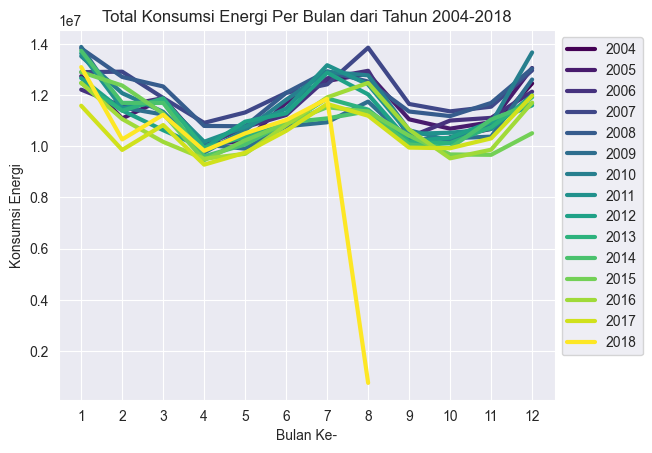

In [8]:
sns.set_style('darkgrid')

ax = sns.lineplot(data=bulanan, x='month', y='AEP_MW', hue='year', palette='viridis', legend='full', lw=3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.title('Total Konsumsi Energi Per Bulan dari Tahun 2004-2018')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('Konsumsi Energi')
plt.xlabel('Bulan Ke-')
plt.show()

In [9]:
jam = pd.DataFrame(df_energy.groupby(['hour', 'year'], group_keys=False)['AEP_MW'].mean())

jam

AEP_MW
hour year              
0    2004  14391.989011
     2005  15047.463014
     2006  14906.550685
     2007  15755.071233
     2008  15691.311475
...                 ...
23   2014  15244.235616
     2015  14884.010959
     2016  14755.005464
     2017  14468.750685
     2018  15290.397196

[360 rows x 1 columns]

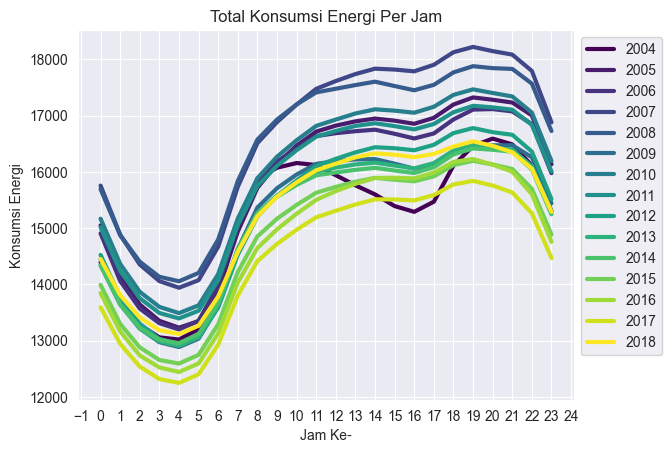

In [11]:
ax = sns.lineplot(data=jam, x='hour', y='AEP_MW', hue='year', palette='viridis', legend='full', lw=3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.title('Total Konsumsi Energi Per Jam')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('Konsumsi Energi')
plt.xlabel('Jam Ke-')
plt.show()

In [14]:
# total rerata konsumsi energi per jam saat weekend dan weekdays

# generate column weekday/weekend
df_energy["day_status"] = df_energy["dayofweek"].map(lambda x: "weekend" if x == 5 or x == 6 else "weekdays")

df_energy.sample(8)

,Datetime,AEP_MW,hour,day,month,year,dayofweek,weekofyear,day_status
60038,2011-05-26 06:00:00,13090.0,6,26,5,2011,3,21,weekdays
4697,2005-09-19 20:00:00,18168.0,20,19,9,2005,0,38,weekdays
73585,2013-11-09 21:00:00,14118.0,21,9,11,2013,5,45,weekend
84329,2014-08-18 14:00:00,18194.0,14,18,8,2014,0,34,weekdays
55447,2011-12-04 22:00:00,15576.0,22,4,12,2011,6,48,weekend
101262,2016-09-11 04:00:00,11259.0,4,11,9,2016,6,36,weekend
39969,2009-09-10 20:00:00,16372.0,20,10,9,2009,3,37,weekdays
53532,2010-02-21 03:00:00,14735.0,3,21,2,2010,6,7,weekend


In [16]:
jam_week = pd.DataFrame(df_energy.groupby(['day_status', 'hour'])['AEP_MW'].mean())

jam_week

AEP_MW
day_status hour              
weekdays   0     14821.925741
           1     14058.361773
           2     13604.705263
           3     13363.001108
           4     13291.754780
           5     13492.847368
           6     14201.130471
           7     15442.113850
           8     16226.425208
           9     16464.445706
           10    16650.857895
           11    16869.560665
           12    16951.889751
           13    17032.936842
           14    17108.610695
           15    17060.147645
           16    16978.884765
           17    17047.180055
           18    17229.343213
           19    17317.127147
           20    17251.253740
           21    17181.375900
           22    16869.397784
           23    15964.509972
weekend    0     14224.474377
           1     13474.270083
           2     12998.656467
           3     12732.288811
           4     12603.925900
           5     12609.756925
           6     12805.578947
           7     13130.554709
           8     13609.842798
           9     14218.173823
           10    14667.849030
           11    14898.202909
           12    15013.895429
           13    15089.933518
           14    15100.181440
           15    15074.468144
           16    15108.559557
           17    15279.185596
           18    15596.932133
           19    15747.731302
           20    15746.538781
           21    15719.882271
           22    15467.891967
           23    14802.804709

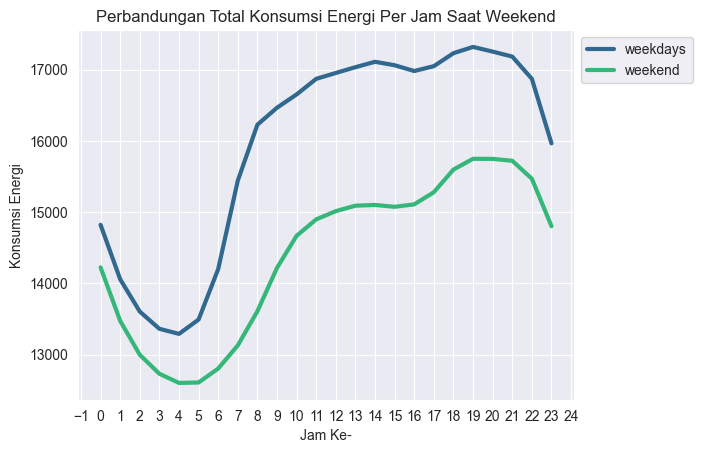

In [18]:
ax = sns.lineplot(data=jam_week, x='hour', y='AEP_MW', hue='day_status', palette='viridis', legend='full', lw=3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.title('Perbandungan Total Konsumsi Energi Per Jam Saat Weekend')
plt.legend(bbox_to_anchor=(1,1))
plt.ylabel('Konsumsi Energi')
plt.xlabel('Jam Ke-')
plt.show()

# Case Study 2: Marketing

In [19]:
sales = pd.read_csv('supermarket_sales_raw.csv')

sales.sample(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,Rating
233,269-04-5750,B,Mandalay,Member,Male,Fashion accessories,73.82,4,14.7640,310.0440,2/21/2019,18:31,Cash,295.28,6.7
603,642-30-6693,B,Mandalay,Normal,Female,Sports and travel,54.51,6,16.3530,343.4130,3/17/2019,13:54,Ewallet,327.06,7.8
825,569-76-2760,A,Yangon,Member,Female,Sports and travel,22.01,4,4.4020,92.4420,1/29/2019,18:15,Credit card,88.04,6.6
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,9.6
113,645-44-1170,A,Yangon,Member,Male,Home and lifestyle,58.07,9,26.1315,548.7615,1/19/2019,20:07,Ewallet,522.63,4.3
296,727-75-6477,C,Naypyitaw,Normal,Male,Electronic accessories,28.84,4,5.7680,121.1280,3/29/2019,14:44,Cash,115.36,6.4
703,729-06-2010,B,Mandalay,Member,Male,Health and beauty,80.47,9,36.2115,760.4415,1/6/2019,11:18,Cash,724.23,9.2
973,531-56-4728,A,Yangon,Normal,Male,Home and lifestyle,80.08,3,12.0120,252.2520,2/11/2019,15:29,Cash,240.24,5.4
979,151-33-7434,B,Mandalay,Normal,Female,Food and beverages,67.77,1,3.3885,71.1585,2/4/2019,20:43,Credit card,67.77,6.5
561,866-99-7614,C,Naypyitaw,Normal,Male,Food and beverages,89.20,10,44.6000,936.6000,2/11/2019,15:42,Credit card,892.00,4.4


In [20]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     1000 non-null   object 
 1   Branch         1000 non-null   object 
 2   City           1000 non-null   object 
 3   Customer type  1000 non-null   object 
 4   Gender         1000 non-null   object 
 5   Product line   1000 non-null   object 
 6   Unit price     1000 non-null   float64
 7   Quantity       1000 non-null   int64  
 8   Tax 5%         1000 non-null   float64
 9   Total          1000 non-null   float64
 10  Date           1000 non-null   object 
 11  Time           1000 non-null   object 
 12  Payment        1000 non-null   object 
 13  cogs           1000 non-null   float64
 14  Rating         1000 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 117.3+ KB


In [24]:
# feature engineering: gross margin percentage and gross income
sales['gross_margin_percentage'] = sales.apply(lambda x: (x['Total']-x['cogs']) * 100 / x['Total'], axis=1)
sales['gross_income'] = sales.apply(lambda x: x['Total'] - x['cogs'], axis=1)

sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,Rating,gross_margin_percentage,gross_income
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,9.1,4.761905,26.1415
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,9.6,4.761905,3.8200
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,7.4,4.761905,16.2155
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,8.4,4.761905,23.2880
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,5.3,4.761905,30.2085


In [26]:
# feature engineering: kolom date, day, month, year, hour
sales['Date'] =  pd.to_datetime(sales['Date'])
sales['Day'] = sales['Date'].dt.day
sales['Month'] = sales['Date'].dt.month
sales['Year'] = sales['Date'].dt.year
sales['Time'] = pd.to_datetime(sales['Time']).dt.hour

sales.head()

/var/folders/34/_j3kcpxd38lfbdvtp0clnhrw0000gn/T/ipykernel_63648/2567623270.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sales['Time'] = pd.to_datetime(sales['Time']).dt.hour


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,Rating,gross_margin_percentage,gross_income,Day,Month,Year
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13,Ewallet,522.83,9.1,4.761905,26.1415,5,1,2019
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10,Cash,76.40,9.6,4.761905,3.8200,8,3,2019
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13,Credit card,324.31,7.4,4.761905,16.2155,3,3,2019
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20,Ewallet,465.76,8.4,4.761905,23.2880,27,1,2019
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10,Ewallet,604.17,5.3,4.761905,30.2085,8,2,2019


In [29]:
# Pada bulan kapan saja akan terjadi lonjakan total sales dan pada produk apa berdasarkan kota?
analisis_1 = pd.DataFrame(
    sales.groupby(['City', 'Product line', 'Month'], group_keys=False)['Total'].sum()
)

analisis_1

Total
City      Product line           Month            
Mandalay  Electronic accessories 1       6699.7770
                                 2       6686.2530
                                 3       3665.4135
          Fashion accessories    1       6112.5960
                                 2       6137.1135
                                 3       4163.6070
          Food and beverages     1       6609.2775
                                 2       5554.8150
                                 3       3050.7960
          Health and beauty      1       6399.8865
                                 2       5856.4275
                                 3       7724.3460
          Home and lifestyle     1       4586.4420
                                 2       4659.8475
                                 3       8302.8750
          Sports and travel      1       6768.0795
                                 2       5529.8145
                                 3       7690.3050
Naypyitaw Electronic accessories 1       5730.2385
                                 2       5473.8810
                                 3       7764.8550
          Fashion accessories    1       6385.0290
                                 2       7699.1145
                                 3       7475.9265
          Food and beverages     1       8315.0235
                                 2       7391.3175
                                 3       8060.5140
          Health and beauty      1       6020.6895
                                 2       5830.3455
                                 3       4764.2910
          Home and lifestyle     1       5594.7045
                                 2       3002.9055
                                 3       5297.9430
          Sports and travel      1       8388.9960
                                 2       3537.4185
                                 3       3835.5135
Yangon    Electronic accessories 1       6401.2725
                                 2       5202.7710
                                 3       6713.0700
          Fashion accessories    1       6847.4910
                                 2       5173.6335
                                 3       4311.3840
          Food and beverages     1       4646.2290
                                 2       7054.2255
                                 3       5462.6460
          Health and beauty      1       3962.5950
                                 2       2915.4825
                                 3       5719.6755
          Home and lifestyle     1      10313.5935
                                 2       4771.6305
                                 3       7331.9715
          Sports and travel      1       6509.9475
                                 2       4742.3775
                                 3       8120.3745

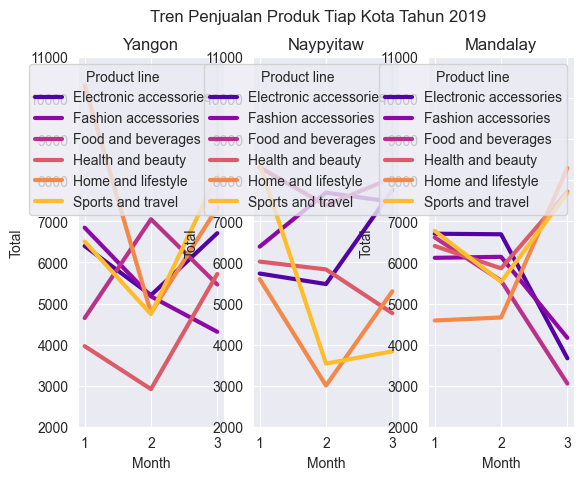

In [31]:
# plot analisis_1 into graph

fig, axes = plt.subplots(1, 3, sharey=False)
fig.suptitle('Tren Penjualan Produk Tiap Kota Tahun 2019')

cities = [k for k in sales['City'].unique()]
for i, kota in enumerate(cities):
    sns.lineplot(data=analisis_1.xs(kota), x='Month', y='Total', 
                 hue='Product line', palette='plasma', legend='full', lw=3, ax=axes[i])
    axes[i].set_title(str(kota))
    axes[i].set_ylim(2000, 11000)
    axes[i].xaxis.set_major_locator(ticker.MultipleLocator(1))